In [1]:
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout
from sklearn.model_selection import train_test_split
from sklearn.utils import extmath
from module_utils import * 
sys.path.append('../utils')
from Structure3 import *
from data_collection import *
#######################     CONFIGURATIONS     ##########################
seed = 29
train = True
save = True

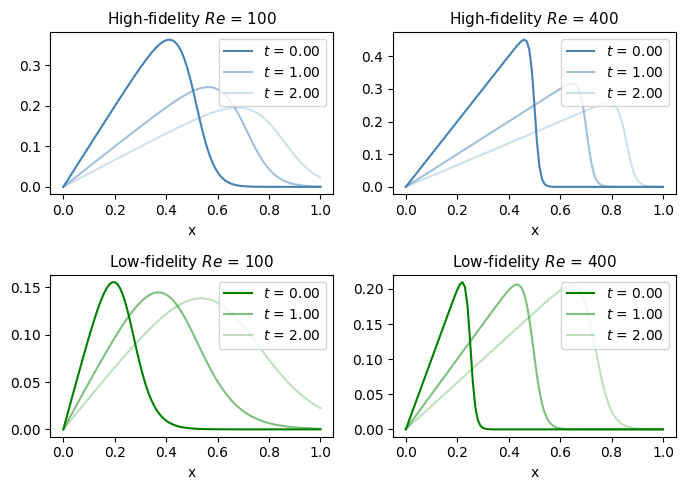

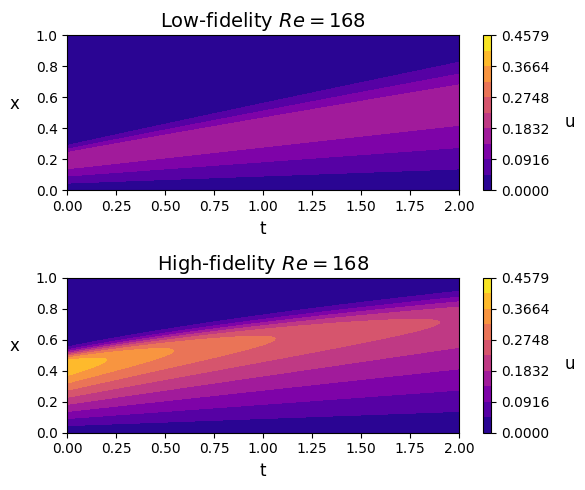

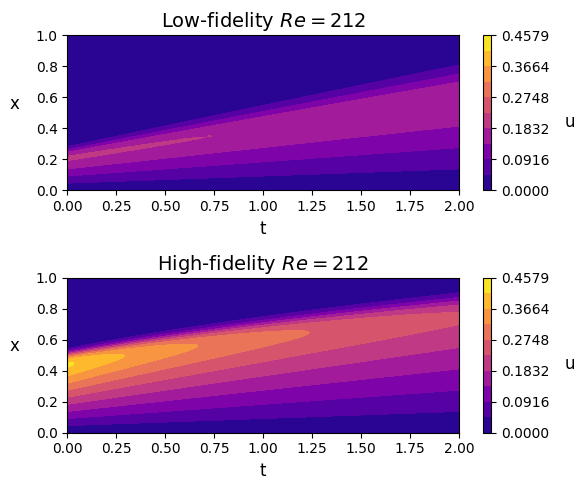

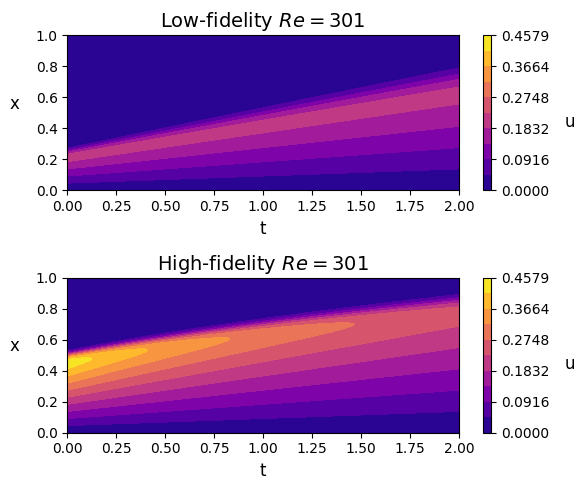

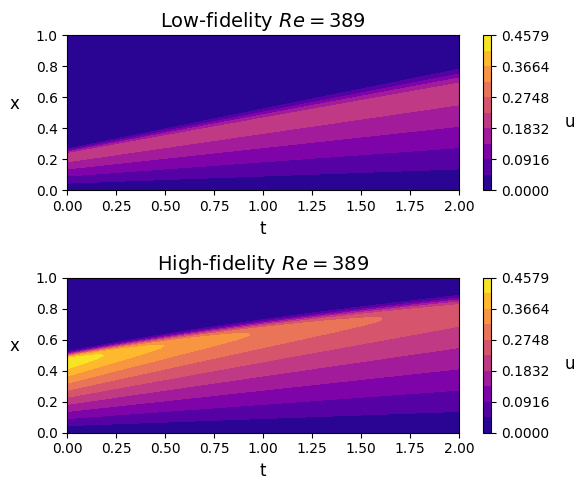

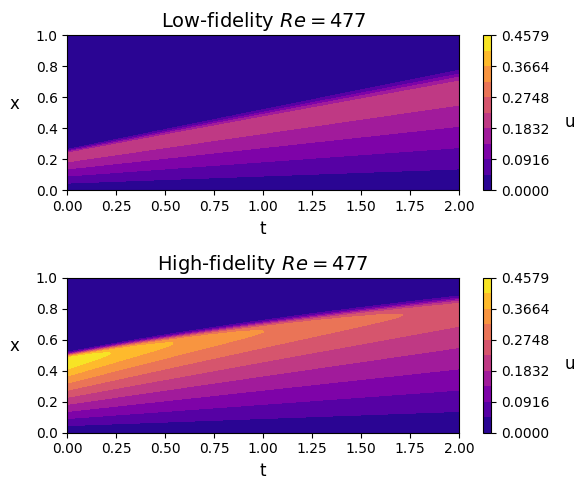

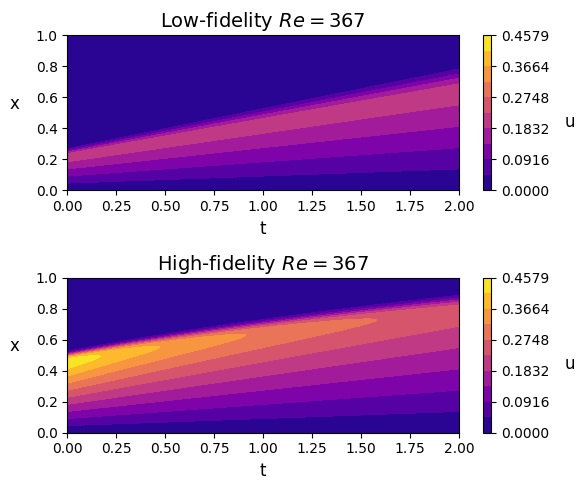

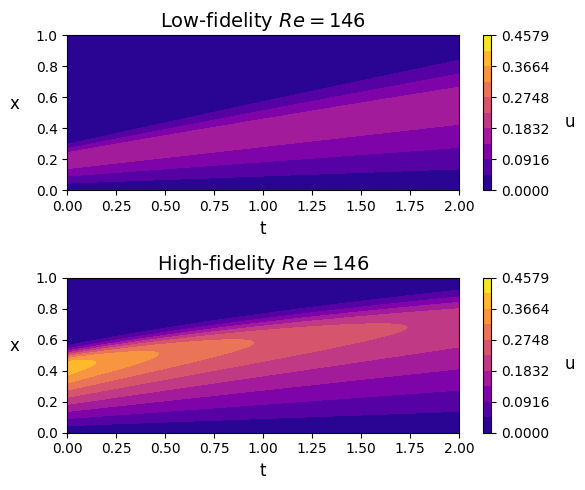

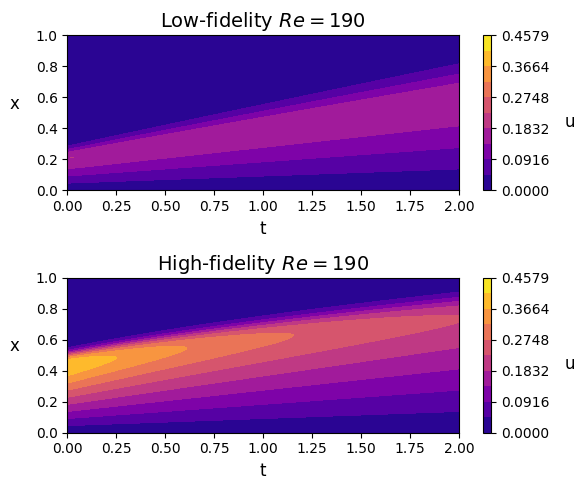

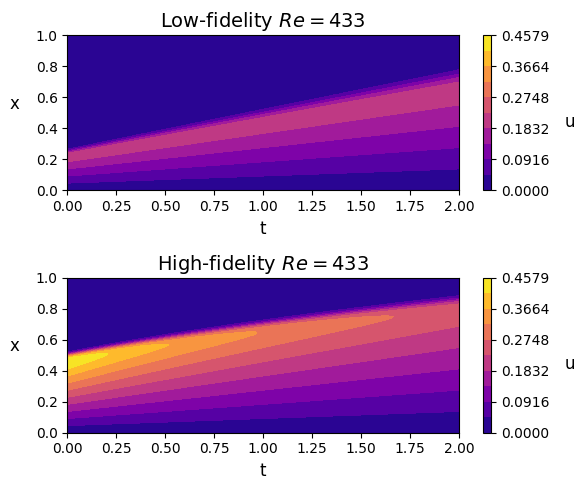

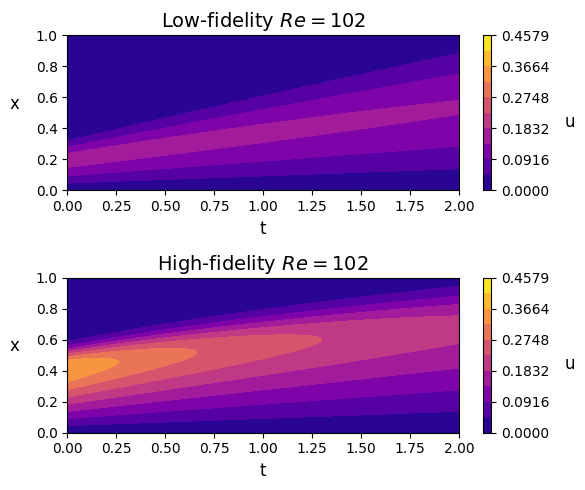

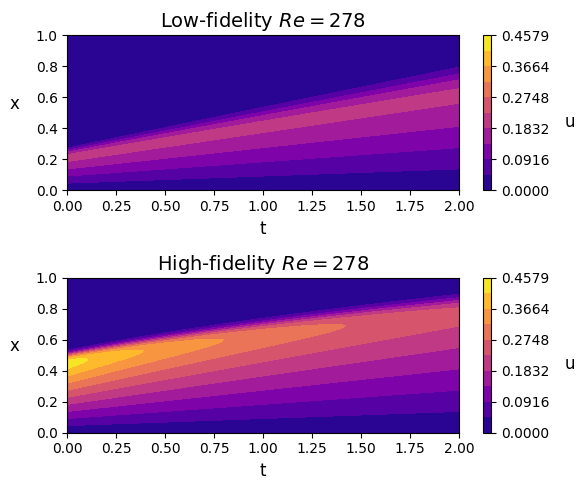

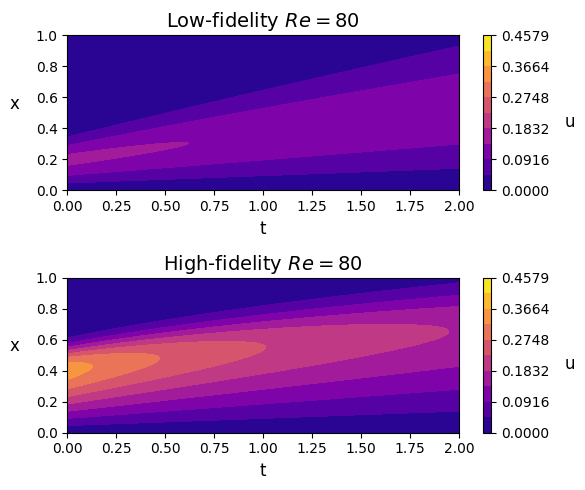

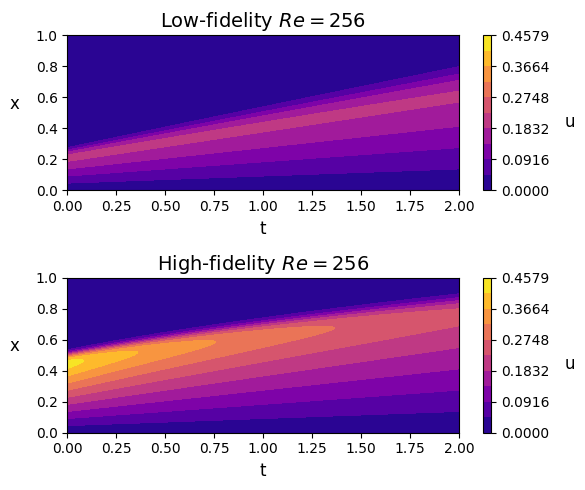

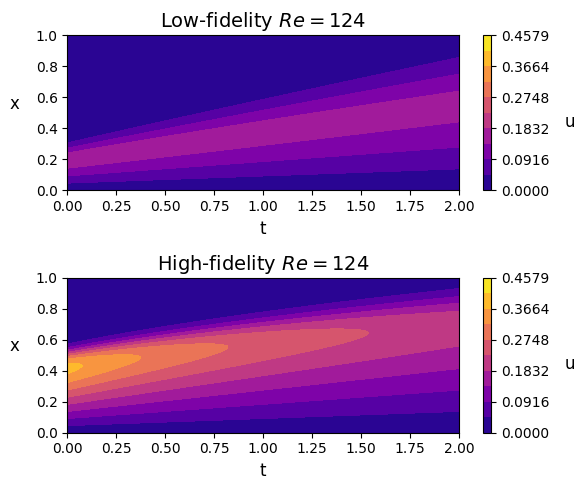

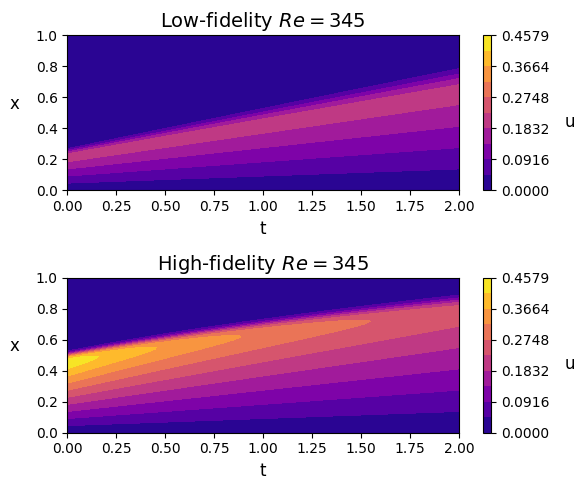

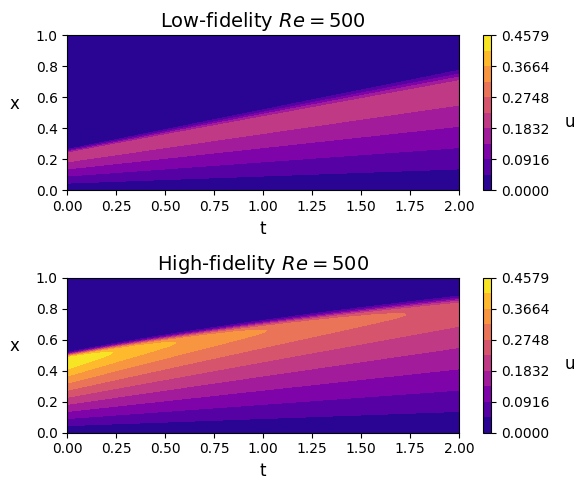

In [2]:
burger_eq = BurgerEquation(nh = 101, nt = 151, T= 2.0, L= 1.0, nre= 20, re_min = 80, re_max= 500, seed=seed)
burger_eq.generate_data()
burger_eq.plot_ground_truth_simulations()
burger_eq.plot_data()

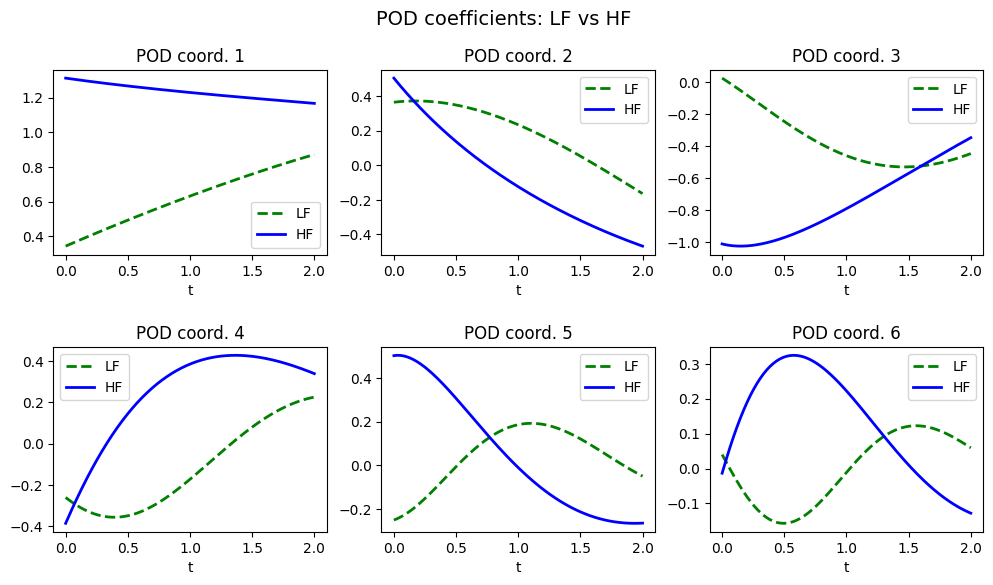

In [3]:
rom = ROM(burger_eq, n_POD=16)

input_train, output_train,input_test, output_test=rom.perform_POD()
rom.plot_POD_coefficients(ind_re=0)

In [4]:
input_train.shape

(20, 151, 18)

In [5]:
a=input_train[:,:,[0,1]].reshape(-1, 2)

In [6]:
a.shape

(3020, 2)

In [7]:
burger_eq.x

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99, 1.  ])

In [8]:
input_train[0,:,0]

array([0.        , 0.01333333, 0.02666667, 0.04      , 0.05333333,
       0.06666667, 0.08      , 0.09333333, 0.10666667, 0.12      ,
       0.13333333, 0.14666667, 0.16      , 0.17333333, 0.18666667,
       0.2       , 0.21333333, 0.22666667, 0.24      , 0.25333333,
       0.26666667, 0.28      , 0.29333333, 0.30666667, 0.32      ,
       0.33333333, 0.34666667, 0.36      , 0.37333333, 0.38666667,
       0.4       , 0.41333333, 0.42666667, 0.44      , 0.45333333,
       0.46666667, 0.48      , 0.49333333, 0.50666667, 0.52      ,
       0.53333333, 0.54666667, 0.56      , 0.57333333, 0.58666667,
       0.6       , 0.61333333, 0.62666667, 0.64      , 0.65333333,
       0.66666667, 0.68      , 0.69333333, 0.70666667, 0.72      ,
       0.73333333, 0.74666667, 0.76      , 0.77333333, 0.78666667,
       0.8       , 0.81333333, 0.82666667, 0.84      , 0.85333333,
       0.86666667, 0.88      , 0.89333333, 0.90666667, 0.92      ,
       0.93333333, 0.94666667, 0.96      , 0.97333333, 0.98666

In [9]:
rom.uhf_train.shape

(20, 151, 16)

The function training took 72.014004 seconds.


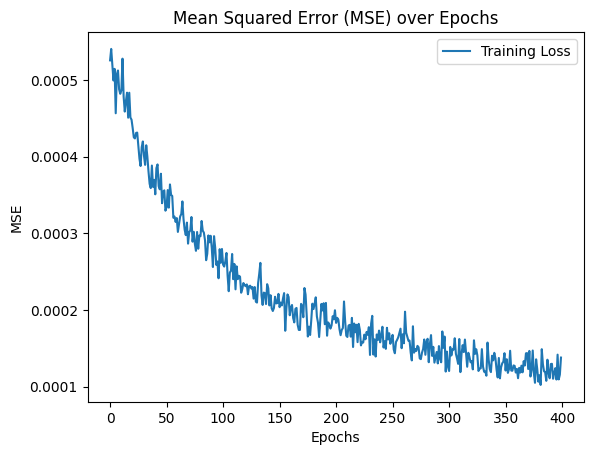

In [10]:

params_NN = { 'lay': 1,
             'nodes': 64,
             'lr':  1e-3,
             'opt': 'Adamax',
             'sequence_freq': 2,
             'sequence_length': 10,
             #'epochs':  500,
             'patience' : 50,
             'dropout' : 0.1}


definition_LSTM = {
    "network_type": "LSTM",
    "params": params_NN,
    "data_train": input_train,
    "output_train": output_train,
    "N": 500,
    "train": True,
    "do_HPO": False,
    "verbose": False
}


model = NetworkFactory.build_network(**definition_LSTM)

output_pred = model.prediction(input_test)
# Plot predicted POD coordinates
 # Re = 235

In [11]:
output_pred.shape

(4, 151, 16)

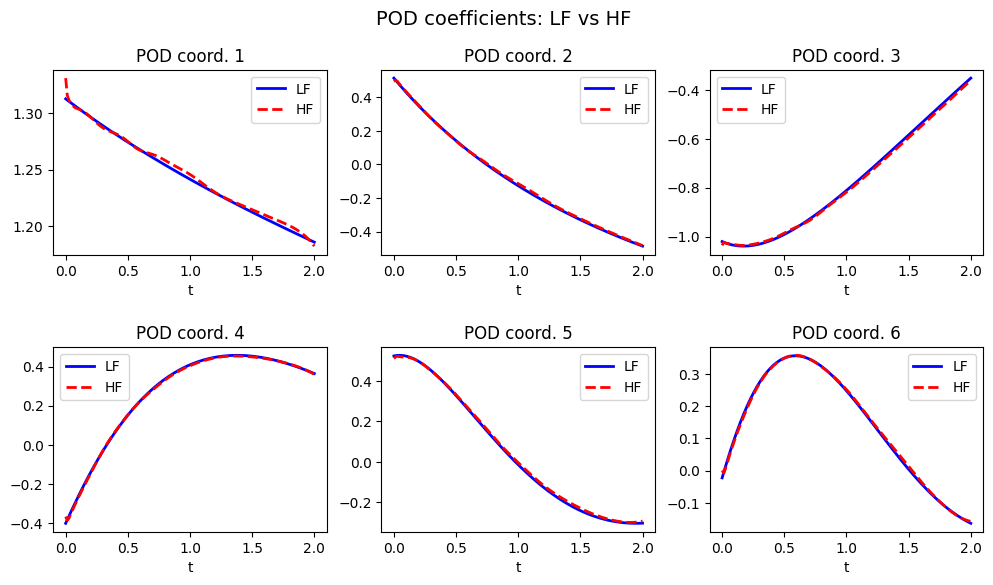

In [12]:
ind_re = [0]
rom.plot_POD_output(ind_re=ind_re, output_pred=output_pred)


In [13]:
rom.output_test.shape

(4, 151, 16)

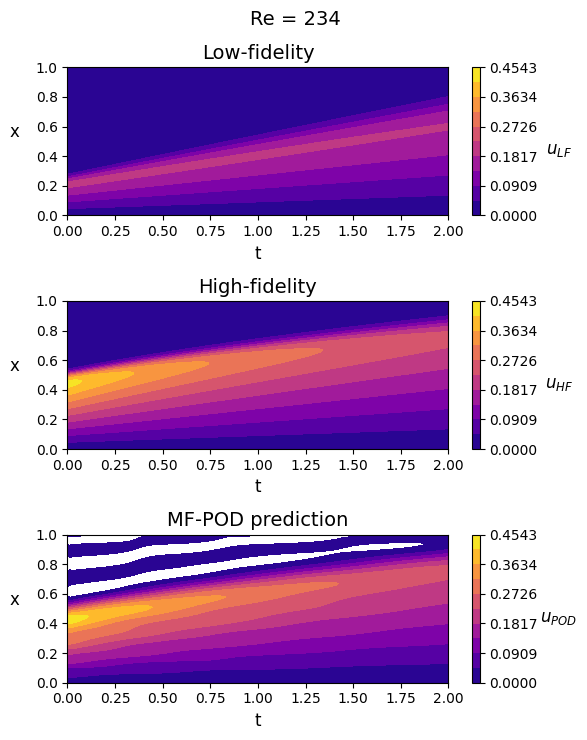

In [14]:
burger_eq.plot_comparison(output_pred, rom.get_basis(), ind_re)


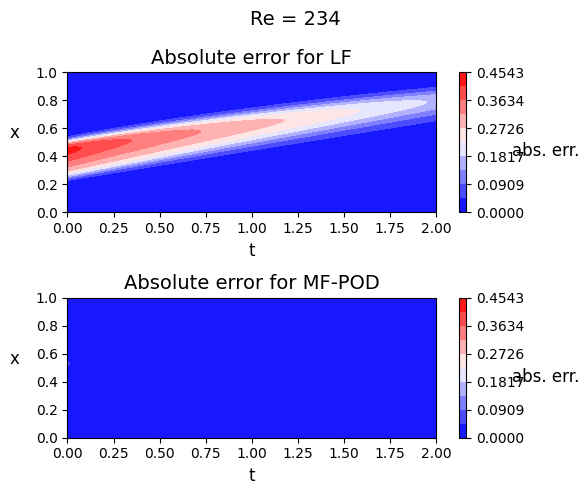

In [15]:
burger_eq.plot_error(output_pred, rom.get_basis(), ind_re)


In [16]:
rom.re_grid_lstm_test

array([[0.36842105, 0.36842105, 0.36842105, 0.36842105, 0.36842105,
        0.36842105, 0.36842105, 0.36842105, 0.36842105, 0.36842105,
        0.36842105, 0.36842105, 0.36842105, 0.36842105, 0.36842105,
        0.36842105, 0.36842105, 0.36842105, 0.36842105, 0.36842105,
        0.36842105, 0.36842105, 0.36842105, 0.36842105, 0.36842105,
        0.36842105, 0.36842105, 0.36842105, 0.36842105, 0.36842105,
        0.36842105, 0.36842105, 0.36842105, 0.36842105, 0.36842105,
        0.36842105, 0.36842105, 0.36842105, 0.36842105, 0.36842105,
        0.36842105, 0.36842105, 0.36842105, 0.36842105, 0.36842105,
        0.36842105, 0.36842105, 0.36842105, 0.36842105, 0.36842105,
        0.36842105, 0.36842105, 0.36842105, 0.36842105, 0.36842105,
        0.36842105, 0.36842105, 0.36842105, 0.36842105, 0.36842105,
        0.36842105, 0.36842105, 0.36842105, 0.36842105, 0.36842105,
        0.36842105, 0.36842105, 0.36842105, 0.36842105, 0.36842105,
        0.36842105, 0.36842105, 0.36842105, 0.36

In [17]:
a

array([[0.        , 0.        ],
       [0.01333333, 0.        ],
       [0.02666667, 0.        ],
       ...,
       [1.97333333, 1.        ],
       [1.98666667, 1.        ],
       [2.        , 1.        ]])

In [18]:
np.max(a[:,0])

2.0

In [19]:
output_test

array([[[ 1.31270012,  0.51332411, -1.02034067, ..., -0.12159365,
          0.06872398,  0.0630974 ],
        [ 1.3115781 ,  0.50150168, -1.0232957 , ..., -0.11517341,
          0.07732808,  0.05319864],
        [ 1.31046261,  0.48980438, -1.0259709 , ..., -0.10783121,
          0.08484319,  0.04291635],
        ...,
        [ 1.18697279, -0.47860272, -0.36419599, ...,  0.02692208,
         -0.03143487,  0.02507359],
        [ 1.18628086, -0.4823138 , -0.35810602, ...,  0.0250846 ,
         -0.03056674,  0.02520283],
        [ 1.18558902, -0.48599937, -0.35202709, ...,  0.02321846,
         -0.02961915,  0.02523316]],

       [[ 1.31303492,  0.51756781, -1.02437127, ..., -0.14780935,
          0.08011728,  0.08381948],
        [ 1.31207434,  0.5056987 , -1.02761609, ..., -0.14074112,
          0.09133273,  0.07171453],
        [ 1.31111793,  0.49395127, -1.03057364, ..., -0.13248723,
          0.10126017,  0.05899952],
        ...,
        [ 1.19928524, -0.49075081, -0.36325257, ...,  

In [20]:
from itertools import product


In [17]:
from itertools import product

def process_data(datahf: np.ndarray, parameters: np.ndarray, t_eval: np.ndarray, Yhf: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Find the elements of a dataset nearest to the given parameters.
    
    Parameters:
    - datahf (np.ndarray): 2D array where datahf[:, 1] contains parameter values.
    - parameters (np.ndarray): 1D array of parameter values to find in datahf.
    - t_eval (np.ndarray): 2D array of evaluation times.
    - Yhf (np.ndarray): 1D array of corresponding y values.
    
    Returns:
    - nearest_x (np.ndarray): 1D array of x values closest to each t_eval.
    - y_obs (np.ndarray): 1D array of corresponding y values from Yhf.
    """
    indices = np.where(datahf[:, 1] == parameters[0])[0]
    if len(indices) == 0:
        raise ValueError(f"No observations related to parameter: {parameters[0]}")
    
    datahf_values = datahf[indices, 0].reshape(-1, 1)
    t_eval_values = t_eval.reshape(1, -1)
    differences = np.abs(datahf_values - t_eval_values)
    closest_indices = np.argmin(differences, axis=0)
    nearest_x = datahf[indices[closest_indices], 0]
    y_obs = Yhf[indices[closest_indices]%indices.shape[0]]
    
    return nearest_x, y_obs

def calculate_cov_likelihood(sigma: float, t_eval: np.ndarray) -> np.ndarray:
    """
    Calculate the covariance matrix for the likelihood.
    
    Parameters:
    - sigma (float): Standard deviation for the likelihood.
    - t_eval (np.ndarray): 2D array of evaluation times.
    
    Returns:
    - cov_likelihood (np.ndarray): 2D array representing the covariance matrix.
    """
    return sigma ** 2 * np.eye(t_eval.shape[0])

def run_simulation(datahf_x: np.ndarray, datahf: np.ndarray, mean_prior: np.ndarray, cov_prior: np.ndarray, Yhf: np.ndarray, 
                   sigma_noise: List[float], n_data: List[int], n_data_x:List[int], parameters: np.ndarray, sigma: np.ndarray, 
                   rwmh_scaling: np.ndarray, rwmh_cov: np.ndarray, rwmh_adaptive: bool, 
                   iterations: int, burnin: int, n_chains: int, final_model: Any, algo: str, 
                   forward_low_fidelity: Optional[Callable] = None) -> Tuple[np.ndarray, np.ndarray]:
    """
    Run a simulation to estimate parameters and calculate errors.
    
    Parameters:
    - datahf_x (np.ndarray): 1D array containing data.
    - datahf (np.ndarray): 2D array containing data  (t and parameter).
    - mean_prior (np.ndarray): 1D array for the mean of the prior.
    - cov_prior (np.ndarray): 2D array for the covariance of the prior.
    - Yhf (np.ndarray): 1D array of observed values.
    - sigma_noise (List[float]): List of noise levels.
    - n_data (List[int]): List of number of data points along t.
    - n_data_x (List[int]): List of number of data points along x.
    - parameters (np.ndarray): 1D array of parameters.
    - sigma (np.ndarray): 1D array of standard deviations for the likelihood.
    - rwmh_scaling (np.ndarray): 1D array of scaling factors for the RWMH algorithm.
    - rwmh_cov (np.ndarray): 2D array for the RWMH covariance.
    - rwmh_adaptive (bool): Boolean indicating if RWMH is adaptive.
    - iterations (int): Integer for the number of iterations.
    - burnin (int): Integer for the burn-in period.
    - n_chains (int): Integer for the number of chains.
    - final_model (Any): The model object with the param_inverse method.
    - algo (str): String indicating the algorithm to use.
    - forward_low_fidelity (Optional[Callable]): Low fidelity forward model function (optional).
    
    Returns:
    - best_estimate (np.ndarray): The best parameter estimate.
    - best_error (np.ndarray): The error corresponding to the best estimate.
    """
    
    # Initialize error and estimate arrays
    error_shape = (len(sigma_noise), len(n_data), len(n_data_x),len(sigma), len(rwmh_scaling))
    error = np.zeros(error_shape)
    estimates = np.zeros(error_shape)
    
    # Iterate over all combinations of parameters using itertools.product
    for (i, noise), (k, n),(w,n_x), (t, s), (j, r) in product(enumerate(sigma_noise), enumerate(n_data), enumerate(n_data_x), enumerate(sigma), enumerate(rwmh_scaling)):
        t_eval = np.linspace(np.min(datahf[:,0]), np.max(datahf[:,0]), n).reshape(-1, 1)  # Generate evaluation times
        x_eval=np.linspace(np.min(datahf_x),np.max(datahf_x),n_x).reshape(-1, 1)
        nearest_x, y_obs = process_data(datahf, parameters, t_eval, Yhf)  # Get nearest t values and observations
        cov_likelihood = calculate_cov_likelihood(s, t_eval)  # Compute the covariance for the likelihood
        
        # Perform parameter estimation and calculate error
        estimates[i, k, w,t, j], error[i, k,w, t, j] = final_model.param_inverse(
            mean_prior, x_eval, t_eval, cov_prior=cov_prior, rmwh_scaling=r, 
            cov_noise=noise, cov_likelihood=cov_likelihood, y_obs=y_obs, 
            x_real=parameters, number_chains=n_chains, N=iterations, 
            burn_in=burnin, diagnostic=True, rwmh_cov=rwmh_cov, 
            rwmh_adaptive=rwmh_adaptive, algo=algo, forward_low_fidelity=forward_low_fidelity
        )
    
    # Identify the index of the minimum error
    smallest_index = np.unravel_index(np.argmin(error), error.shape)
    best_estimate = estimates[smallest_index]
    best_error = error[smallest_index]
    
    # Print the best parameters
    print(f"The best estimate is given by: sigma_noise={sigma_noise[smallest_index[0]]}, "
          f"number of data={n_data[smallest_index[1]]}, sigma={sigma[smallest_index[2]]}, "
          f"rwmh_scaling={rwmh_scaling[smallest_index[3]]}")

    return best_estimate, best_error

In [46]:
[rom.re_grid_lstm_test[0,0]]

[0.3684210526315789]

In [17]:
burger_eq.set_POD(16,rom.get_basis())

In [18]:
burger_eq.n_POD

16

: 

Sampling chain 1/2


Running chain, α = 0.23: 100%|██████████| 30/30 [00:06<00:00,  4.81it/s]


Sampling chain 2/2


Running chain, α = 0.20: 100%|██████████| 30/30 [00:05<00:00,  5.39it/s]
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [0.278]
     mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  0.278  0.01   0.269    0.288      0.004    0.003       5.0       5.0   

          r_hat  
x0  92155435.79  
Autocorrelation...


c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\stats\density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")


The difference between estimated values [0.09042105]



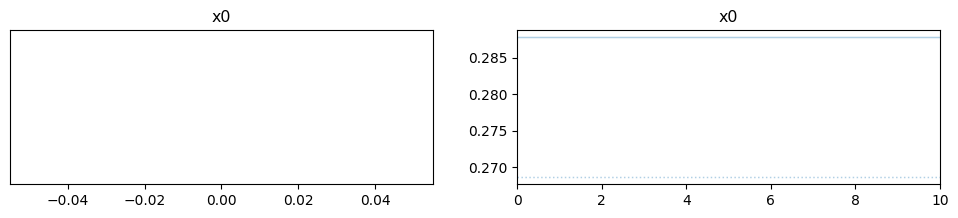

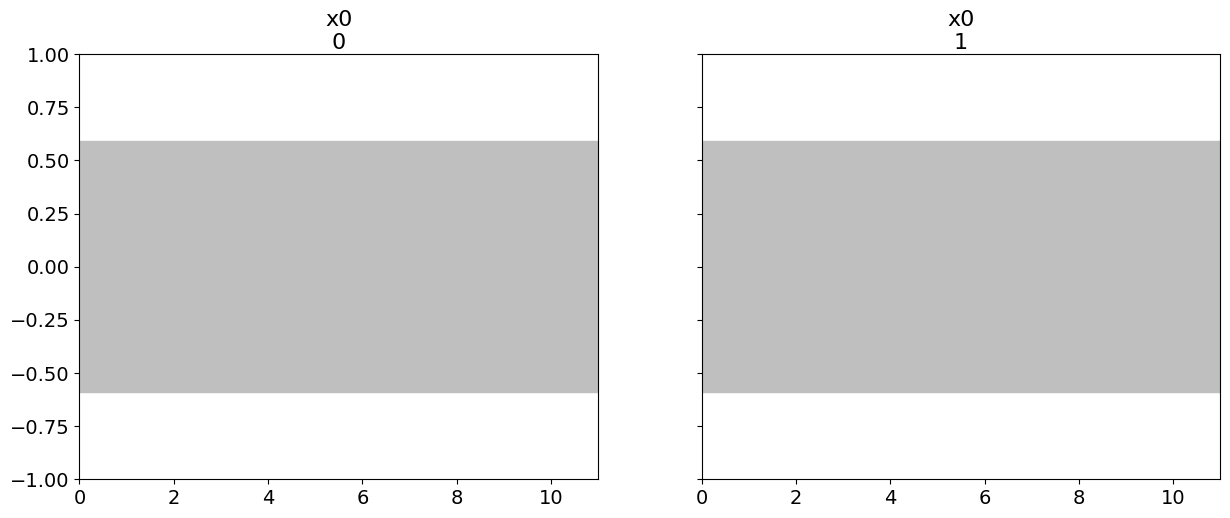

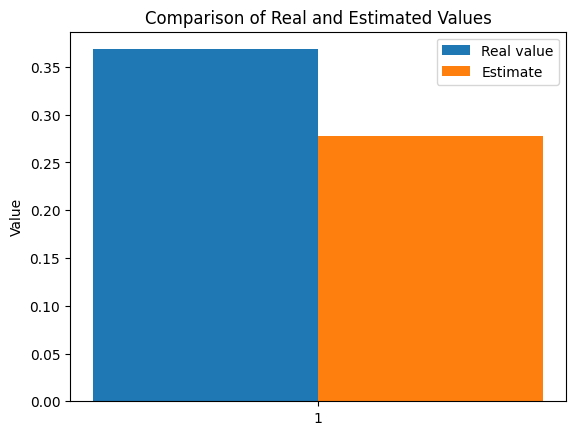

The function param_inverse took 14.003967 seconds.
Sampling chain 1/2


Running chain, α = 0.28:  57%|█████▋    | 17/30 [00:03<00:02,  5.28it/s]

In [19]:
# true parameters
sigma_noise=[0.05,0.1]
n_data=[110]
index_re=0
parameter=np.array([rom.re_grid_lstm_test[index_re,0]])
#indices = np.where(input_test[:,:,1] == parameter)[0]
mean_prior=np.array([.5])
cov_prior=np.diag([.5])
# cov_linkelihood
sigma=np.array([0.3,0.5,1,2,4.])   # NB, con sigma piccolo (e.g. 1) funzia, sigma troppo gaìrande no

# adaptive metropolis
rwmh_cov = np.eye(1)
rmwh_scaling = np.array([0.5,0.2])    # 0.05 sembra problema sia esplorazione
rwmh_adaptive = True
iterations =30
burnin = 20
n_chains=2

algo="MH"


estimateMF, errorMF= run_simulation(datahf_x=burger_eq.x, datahf=rom.input_train[:,:,[0,1]].reshape(-1, 2), mean_prior=mean_prior, cov_prior=cov_prior, Yhf=output_train[index_re,], 
                   sigma_noise=sigma_noise, n_data=n_data, n_data_x=[101],parameters=parameter, sigma=sigma, 
                   rwmh_scaling=rmwh_scaling, rwmh_cov=rwmh_cov, rwmh_adaptive=rwmh_adaptive, 
                   iterations=iterations, burnin=burnin, n_chains= n_chains, final_model=model, algo=algo, 
                   forward_low_fidelity= burger_eq._forward_low_fidelity)

In [9]:
mean_prior =np.array([2.3,0.9,0.4,1.1])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])

sigma_noise = [0.25,0.5]
n_data = [50,30]
parameters =np.array([3.,1.2,1.35,1.825])
sigma = np.array([ 4.,2.])
rwmh_scaling = np.array([ 2.,0.5,1.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 300
burnin = 200
n_chains = 2
algo = "MH"


estimateMF, errorMF= run_simulation(x_HF, mean_prior, cov_prior, y_HF, sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo)


NameError: name 'x_HF' is not defined